# Assignment 02 - Group [12]

## Group Members
1. Ben Changdar
2. Kur Malual
3. Matthew Tuurozeeng
4. Daniel Kpatamia
5. Inares Tsanue

## Prompt Library
### Prompts we used for this assignment include:

e.g
*   Question 1A - "[prompt]"
*   Question 2B - "[prompt]"



how does filtering works with pandas?
how do you identify missing values in a csv file with python?
which of these models is good for csv data with only two variables and why?Choose two models out of these
i. Linear Regression
ii. Polynomial Regression
iii. Moving Average / ExponenBal Smoothing

*Some Resources Used*
*1.https://youtu.be/c9vhHUGdav0?si=SJj4XeFjGwqf6iB0*
*2.https://youtu.be/VXtjG_GzO7Q?si=M1-QAvUVcXosetpE*
*3.https://youtu.be/0B5eIE_1vpU?si=wrceDZLlbjGb6AgZ*

# Question 1A - Ghana vs Mauritius

In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('life-expectancy.csv')

In [2]:
ghana = df[df['Entity'] == 'Ghana'][['Year', 'Life expectancy']]
mauritius = df[df['Entity'] == 'Mauritius'][['Year', 'Life expectancy']]


nigeria = df[df['Entity'] == 'Nigeria'][['Year', 'Life expectancy']]


gm = pd.merge(ghana, mauritius, on='Year', suffixes=('_Ghana', '_Mauritius'))
gm = gm.sort_values('Year')

start_year = gm['Year'].min()
end_year = gm['Year'].max()

start_year, end_year

(1950, 2023)

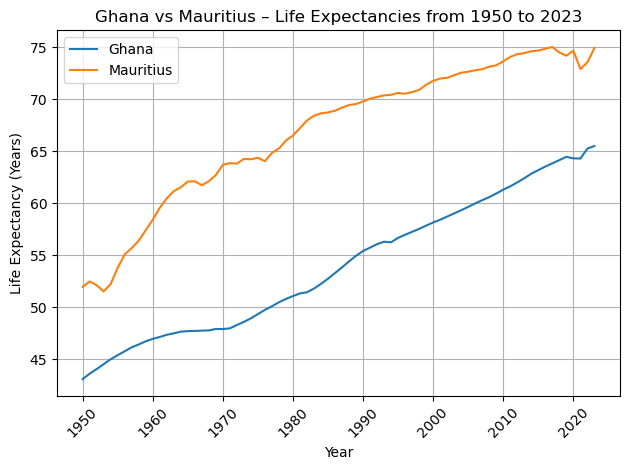

In [3]:
plt.figure()
plt.plot(gm['Year'], gm['Life expectancy_Ghana'])
plt.plot(gm['Year'], gm['Life expectancy_Mauritius'])

plt.title(f"Ghana vs Mauritius – Life Expectancies from {start_year} to {end_year}")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.xticks(rotation=45)
plt.legend(["Ghana", "Mauritius"])
plt.tight_layout()
plt.grid(True)
plt.show()



---



# Question 1B - Third Country


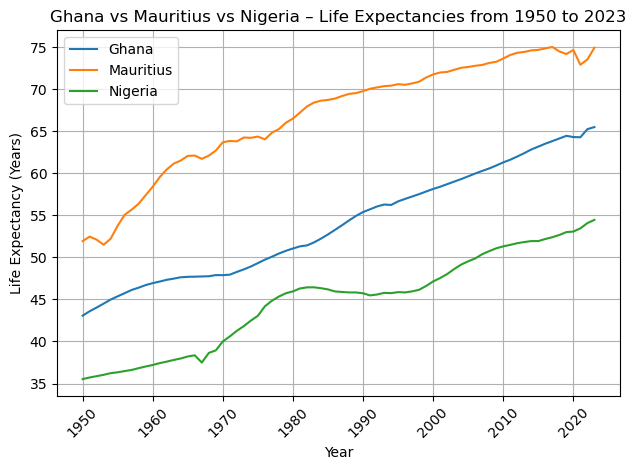

In [4]:
# Solution here
gmn = pd.merge(gm, nigeria, on='Year')
gmn = gmn.rename(columns={'Life expectancy': 'Life expectancy_Nigeria'})

plt.figure()
plt.plot(gmn['Year'], gmn['Life expectancy_Ghana'])
plt.plot(gmn['Year'], gmn['Life expectancy_Mauritius'])
plt.plot(gmn['Year'], gmn['Life expectancy_Nigeria'])

plt.title(f"Ghana vs Mauritius vs Nigeria – Life Expectancies from {start_year} to {end_year}")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.xticks(rotation=45)
plt.legend(["Ghana", "Mauritius", "Nigeria"])
plt.tight_layout()
plt.grid(True)
plt.show()



---



# Question 1C - Missing Data


##Q1c i - Missing Values


In [6]:
# Solution here
countries = ['Ghana', 'Mauritius', 'Nigeria']
data = df[df['Entity'].isin(countries)][['Entity', 'Year', 'Life expectancy']]

print("Missing Values Per Country:")
missing_values = data.groupby('Entity')['Life expectancy'].apply(lambda x: x.isna().sum())
print(missing_values)
print("\n")


Missing Values Per Country:
Entity
Ghana        0
Mauritius    0
Nigeria      0
Name: Life expectancy, dtype: int64




##Q1c ii - Outliers or Suspicious jumps


In [ ]:
# Solution here

print("Suspicious Jumps that have >5 years change:")

suspicious_records = []

for country in countries:
    country_df = data[data['Entity'] == country].sort_values('Year').copy()
    country_df['Diff'] = country_df['Life expectancy'].diff()

    suspicious = country_df[np.abs(country_df['Diff']) > 5]

    if not suspicious.empty:
        print(f"\n{country}:")
        print(suspicious[['Year', 'Life expectancy', 'Diff']])
        suspicious_records.append(suspicious)

print("\n")

Suspicious Jumps (>5 years change):

Ghana:
      Year  Life expectancy     Diff
6937  1950          43.0716  15.0716

Mauritius:
       Year  Life expectancy     Diff
12223  1947          38.6180   5.3300
12224  1950          51.9377  13.3197




##Q1c iii - Handling Missing Data


In [9]:
# Solution here
cleaned_data = data.copy()

for country in countries:
    mask = cleaned_data['Entity'] == country
    cleaned_data.loc[mask, 'Life expectancy'] = (
        cleaned_data[mask]
        .sort_values('Year')['Life expectancy']
        .interpolate(method='linear')
        .values
    )

##Q1c iv - Graphs


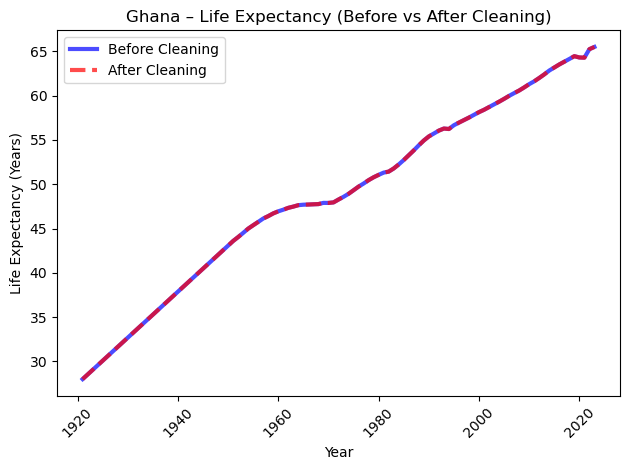

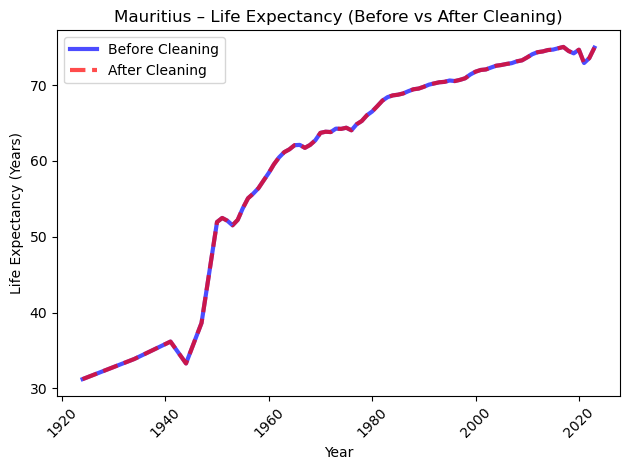

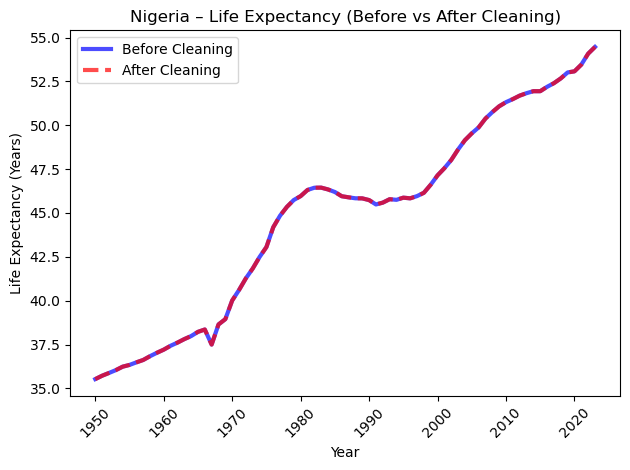

In [17]:
# Solution here
for country in countries:
    before = data[data['Entity'] == country].sort_values('Year')
    after = cleaned_data[cleaned_data['Entity'] == country].sort_values('Year')

    plt.figure()
    plt.plot(before['Year'], before['Life expectancy'],linewidth=3, color='blue', label="Before Cleaning", alpha=0.7)
    plt.plot(after['Year'], after['Life expectancy'], linewidth=3, linestyle='dashed', color='red', label="After Cleaning", alpha=0.7)

    plt.title(f"{country} – Life Expectancy (Before vs After Cleaning)")
    plt.xlabel("Year")
    plt.ylabel("Life Expectancy (Years)")
    plt.legend(["Before Cleaning", "After Cleaning"])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



---



# Question 1D - Statistcs


In [18]:
# Solution here
countries = ['Ghana', 'Mauritius', 'Nigeria']

data = df[df['Entity'].isin(countries)][['Entity', 'Year', 'Life expectancy']]

stats = data.groupby('Entity')['Life expectancy'].agg(
    Mean='mean',
    Median='median',
    Std_Deviation='std',
    Minimum='min',
    Maximum='max'
)

data['Decade'] = (data['Year'] // 10) * 10
decade_avg = data.groupby(['Entity', 'Decade'])['Life expectancy'].mean().reset_index()

decade_avg['Growth Rate (%)'] = (
    decade_avg.groupby('Entity')['Life expectancy']
    .pct_change() * 100
)

decade_avg = decade_avg.round({
    'Life expectancy': 2,
    'Growth Rate (%)': 2
})

print(decade_avg)
print(stats)

       Entity  Decade  Life expectancy  Growth Rate (%)
0       Ghana    1920            28.00              NaN
1       Ghana    1950            45.06            60.91
2       Ghana    1960            47.53             5.49
3       Ghana    1970            49.20             3.51
4       Ghana    1980            52.70             7.11
5       Ghana    1990            56.59             7.39
6       Ghana    2000            59.50             5.14
7       Ghana    2010            62.93             5.76
8       Ghana    2020            64.83             3.03
9   Mauritius    1920            31.22              NaN
10  Mauritius    1930            33.87             8.50
11  Mauritius    1940            36.02             6.35
12  Mauritius    1950            53.85            49.49
13  Mauritius    1960            61.18            13.60
14  Mauritius    1970            64.43             5.32
15  Mauritius    1980            68.45             6.24
16  Mauritius    1990            70.49          

*the NaN at the beginning of every grwoth rate is due to the fact that there is previous value to compute with the current value to calculate the growth rate*



---



#Question 2 - Ghana's Life Expectancy

In [19]:
# Solution here
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [20]:
ghana = df[df['Entity'] == 'Ghana'][['Year', 'Life expectancy']].dropna()
ghana = ghana.sort_values('Year')

X = ghana[['Year']].values
y = ghana['Life expectancy'].values


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

poly = PolynomialFeatures(degree=3) 
X_poly = poly.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)


future_years = np.arange(ghana['Year'].min(), 2051).reshape(-1, 1)

lin_pred = lin_reg.predict(future_years)
poly_pred = poly_reg.predict(poly.transform(future_years))




---



#Question 3 - Actual vs Predicted

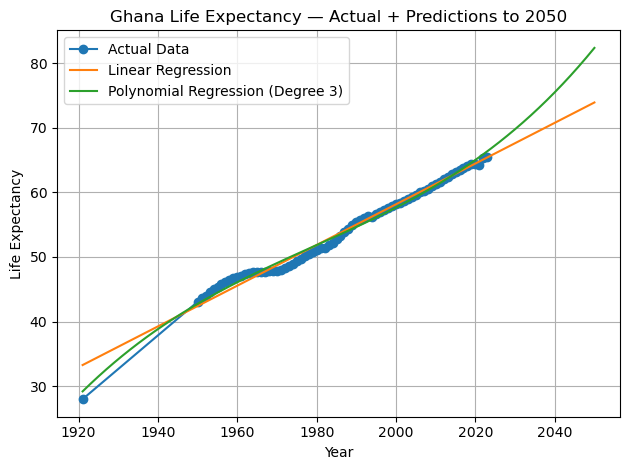

In [22]:
plt.figure()
plt.plot(ghana['Year'], y, marker='o', label="Actual Data")
plt.plot(future_years.flatten(), lin_pred, label="Linear Regression")
plt.plot(future_years.flatten(), poly_pred, label="Polynomial Regression (Degree 3)")

plt.title("Ghana Life Expectancy — Actual + Predictions to 2050")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()